In [3]:
from langgraph.graph import StateGraph, START, END

In [4]:
from langchain_ollama import ChatOllama
from dotenv import load_dotenv 
load_dotenv() 
from typing import TypedDict 

In [5]:
import os 
llm = ChatOllama(
    model="gpt-oss:20b-cloud",
    base_url = os.getenv("OLLAMA_BASE_URL"),
    headers = {"Authorization":f"Bearer {os.getenv("OLLAMA_API_KEY")}"}
)

CODING


In [ ]:
class BatsmanClass(TypedDict):
    runs:int 
    balls:int 
    fours:int 
    sixes:int 
    strikerate:float 
    balls_per_boundary:float 
    boundary_percentage:float 
    summary: str 

In [42]:
def calc_sr(state:BatsmanClass)->BatsmanClass:
    strikerate = (state['runs']/state['balls'])*100
    # state['strikerate']=strikerate  
    return {'strikerate':strikerate}  #cant return whole state since its parallel so jst we return whats updated 

In [43]:
def bpb(state:BatsmanClass)->BatsmanClass:
    bouns=state['balls']/(state['fours']+state['sixes']) 
    # state['balls_per_boundary']=bouns 
    return {'balls_per_boundary':bouns}

In [44]:
def percentOfBoun(state:BatsmanClass)->BatsmanClass: 
    tot=4*state['fours']+6*state['sixes'] 
    val=(tot/state['runs'])*100 
    # state['boundary_percentage']=val 
    return {'boundary_percentage':val} 

In [45]:
def summary(state:BatsmanClass)->BatsmanClass: 
   summary = f""" 
    Strike Rate: {state['strikerate']} \n 
    Balls Per Boundary : {state['balls_per_boundary']} \n 
    Percentage of Boundaries : {state['boundary_percentage']} \n 
    """
   state['summary']=summary 
   return state 

In [46]:
#define a graph 
graph = StateGraph(BatsmanClass) 
#add nodes 
graph.add_node('Strike Rate',calc_sr) 
graph.add_node('Balls Per Boundary',bpb)
graph.add_node('Boundary Percentage',percentOfBoun) 
graph.add_node('summary',summary) 
#add edges 
graph.add_edge(START,'Strike Rate') 
graph.add_edge(START,'Balls Per Boundary') 
graph.add_edge(START,'Boundary Percentage')
graph.add_edge('Strike Rate','summary') 
graph.add_edge('Balls Per Boundary','summary')
graph.add_edge('Boundary Percentage','summary')
graph.add_edge('summary',END) 
#compile it 
workflow=graph.compile() 

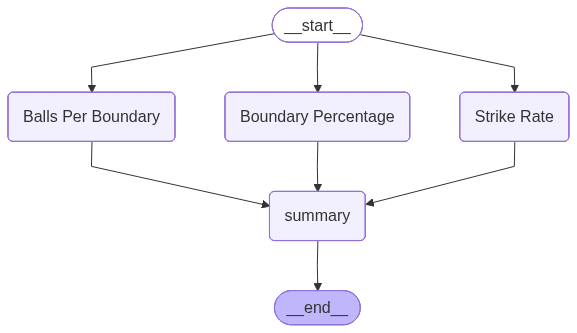

In [47]:
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())

In [48]:
vals = {
    'runs':100,
    'balls':50,
    'fours':8,
    'sixes':4
}
workflow.invoke(vals) 

{'runs': 100,
 'balls': 50,
 'fours': 8,
 'sixes': 4,
 'strikerate': 200.0,
 'balls_per_boundary': 4.166666666666667,
 'boundary_percentage': 56.00000000000001}